In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [21]:
df = pd.read_excel("customer.xlsx")
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [22]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [26]:
df.dropna(inplace=True) 
# Remove null values of description & Customer id
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [25]:
df.shape

(406829, 8)

In [29]:
# ML models need numbers, not text
# LabelEncoder converts: "UK" -> 0, "France" -> 1, etc. Covert country text into numeric values
le = LabelEncoder()
df['Country'] = le.fit_transform(df['Country'])

print("Encoded Country values:", df['Country'].unique())
print("Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

Encoded Country values: [35 13  0 23 14 24 10 32 30 25 26 18  3 21 19 16  6  9  7 31  1 17 12 15
 29 20 34 28  8  5 36  4 33 11  2 22 27]
Mapping: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3), np.int64(4): np.int64(4), np.int64(5): np.int64(5), np.int64(6): np.int64(6), np.int64(7): np.int64(7), np.int64(8): np.int64(8), np.int64(9): np.int64(9), np.int64(10): np.int64(10), np.int64(11): np.int64(11), np.int64(12): np.int64(12), np.int64(13): np.int64(13), np.int64(14): np.int64(14), np.int64(15): np.int64(15), np.int64(16): np.int64(16), np.int64(17): np.int64(17), np.int64(18): np.int64(18), np.int64(19): np.int64(19), np.int64(20): np.int64(20), np.int64(21): np.int64(21), np.int64(22): np.int64(22), np.int64(23): np.int64(23), np.int64(24): np.int64(24), np.int64(25): np.int64(25), np.int64(26): np.int64(26), np.int64(27): np.int64(27), np.int64(28): np.int64(28), np.int64(29): np.int64(29), np.int64(30): np.int64(30), np.i

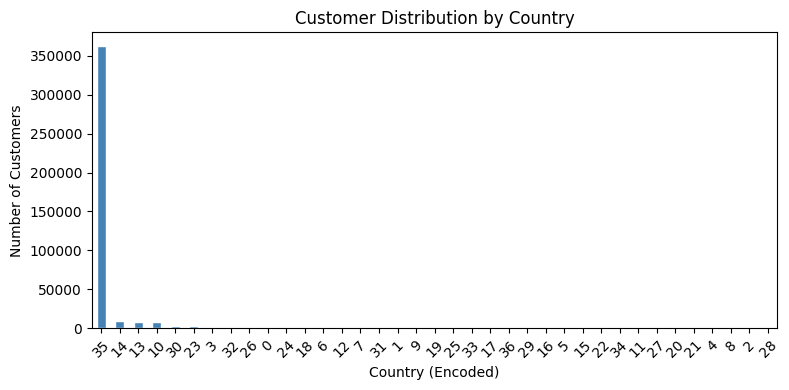

In [30]:
# Bar chart: number of customers per country
plt.figure(figsize=(8, 4))
df['Country'].value_counts().plot(kind='bar', color='steelblue', edgecolor='white')

plt.title('Customer Distribution by Country')
plt.xlabel('Country (Encoded)')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
# X = input columns the model learns patterns from
# y = the column you want the model to predict

X = df[['Quantity', 'UnitPrice']]   # features
y = df['Country']                    # target label

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nSample X:\n", X.head())
print("\nSample y:\n", y.head())

Features shape: (406829, 2)
Target shape: (406829,)

Sample X:
    Quantity  UnitPrice
0         6       2.55
1         6       3.39
2         8       2.75
3         6       3.39
4         6       3.39

Sample y:
 0    35
1    35
2    35
3    35
4    35
Name: Country, dtype: int64


In [32]:
# 80% data for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% goes to test
    random_state=42     # ensures same split every run
)

print("Training samples:", X_train.shape[0])
print("Testing  samples:", X_test.shape[0])

Training samples: 325463
Testing  samples: 81366


In [33]:
# Logistic Regression: finds a linear boundary between classes
lr_model = LogisticRegression(max_iter=200)
lr_model.fit(X_train, y_train)          # train

lr_pred = lr_model.predict(X_test)      # predict on test data
lr_acc  = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", round(lr_acc, 4))
print("Confusion Matrix:\n", confusion_matrix(y_test, lr_pred))

Logistic Regression Accuracy: 0.8896
Confusion Matrix:
 [[    0     0     0 ...     0   229     0]
 [    0     0     0 ...     0    78     0]
 [    0     0     0 ...     0     5     0]
 ...
 [    0     0     0 ...     0    13     0]
 [    0     0     0 ...     0 72379     0]
 [    0     0     0 ...     0    43     0]]


C:\Users\Findingpi\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [34]:
# Decision Tree: splits data by asking yes/no questions
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
dt_acc  = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", round(dt_acc, 4))
print("Confusion Matrix:\n", confusion_matrix(y_test, dt_pred))

Decision Tree Accuracy: 0.8903
Confusion Matrix:
 [[   13     0     0 ...     0   197     0]
 [    0     0     0 ...     0    75     0]
 [    0     0     0 ...     0     5     0]
 ...
 [    0     0     0 ...     0    13     0]
 [   21     0     0 ...     1 72219     0]
 [    0     0     0 ...     0    43     0]]


In [35]:
# KNN: classifies based on the K nearest data points
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)
knn_acc  = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", round(knn_acc, 4))
print("Confusion Matrix:\n", confusion_matrix(y_test, knn_pred))

KNN Accuracy: 0.8852
Confusion Matrix:
 [[   18     0     0 ...     0   180     0]
 [    0     1     0 ...     0    75     0]
 [    0     0     0 ...     0     5     0]
 ...
 [    0     0     0 ...     0    12     0]
 [   36     1     0 ...     0 71772     0]
 [    0     0     0 ...     0    43     0]]


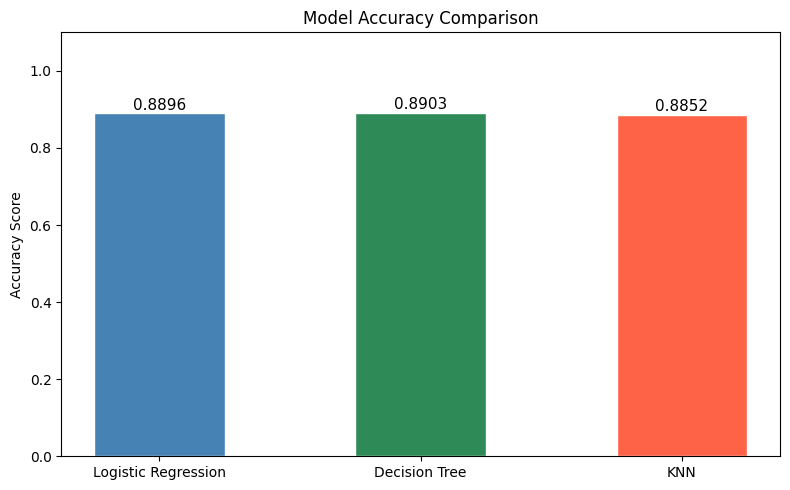


--- Summary ---
Logistic Regression      : 0.8896
Decision Tree            : 0.8903
KNN                      : 0.8852


In [36]:
# Collect all accuracies
model_names = ['Logistic Regression', 'Decision Tree', 'KNN']
accuracies  = [lr_acc, dt_acc, knn_acc]
colors      = ['steelblue', 'seagreen', 'tomato']

# Plot comparison bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies, color=colors, edgecolor='white', width=0.5)

# Add accuracy labels on top of each bar
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.01,
             f"{acc:.4f}", ha='center', fontsize=11)

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

# Print summary table
print("\n--- Summary ---")
for name, acc in zip(model_names, accuracies):
    print(f"{name:25s}: {acc:.4f}")